# NMC data QC 

# Import Required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import anndata as ad
import scanpy as sc
import yaml
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Required Inputs

In [2]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
metadata_dir = Path(config['metadata_dir'])
preprocessed_dir = Path(config['preprocessed_dir'])

# make a roi list of directories in preprocessed_dir that are not .DS_Store
roi_list = [roi for roi in preprocessed_dir.iterdir() if roi.is_dir() and roi.name != '.DS_Store']


# Extract Patients metadata

In [7]:
patients_metadata = pd.read_excel(metadata_dir / 'patient_metadata.xlsx')
patients_metadata.dropna(inplace=True)
patients_metadata.head()
#extract from the patients_metadata "outcome" column only the digits 
patients_metadata["outcome"] = patients_metadata["outcome"].str.extract('(\d+)').astype(int)
#add a new column if the  "outcome" column is greater than 9
patients_metadata["outcome_group"] = np.where(patients_metadata["outcome"] > 6, "long_term survival", "short_term survival")
patients_metadata["rois"] = patients_metadata["rois"].astype(str)
patients_metadata['rois'] = patients_metadata['rois'].str.split(r'\+ ')
patients_metadata = patients_metadata.explode('rois', ignore_index=True)
patients_metadata['rois'] = patients_metadata['rois'].str.strip()
patients_metadata["exp_name"] = "Run" +  patients_metadata['run'].astype(int).astype(str) + '_ROI' + patients_metadata['rois'].astype(str)

## Export the new patients metadata object format 

In [10]:
patients_metadata.to_csv(metadata_dir / 'new_patients_metadata.csv', index=False)

## Compare number of ROIS based on the survival time

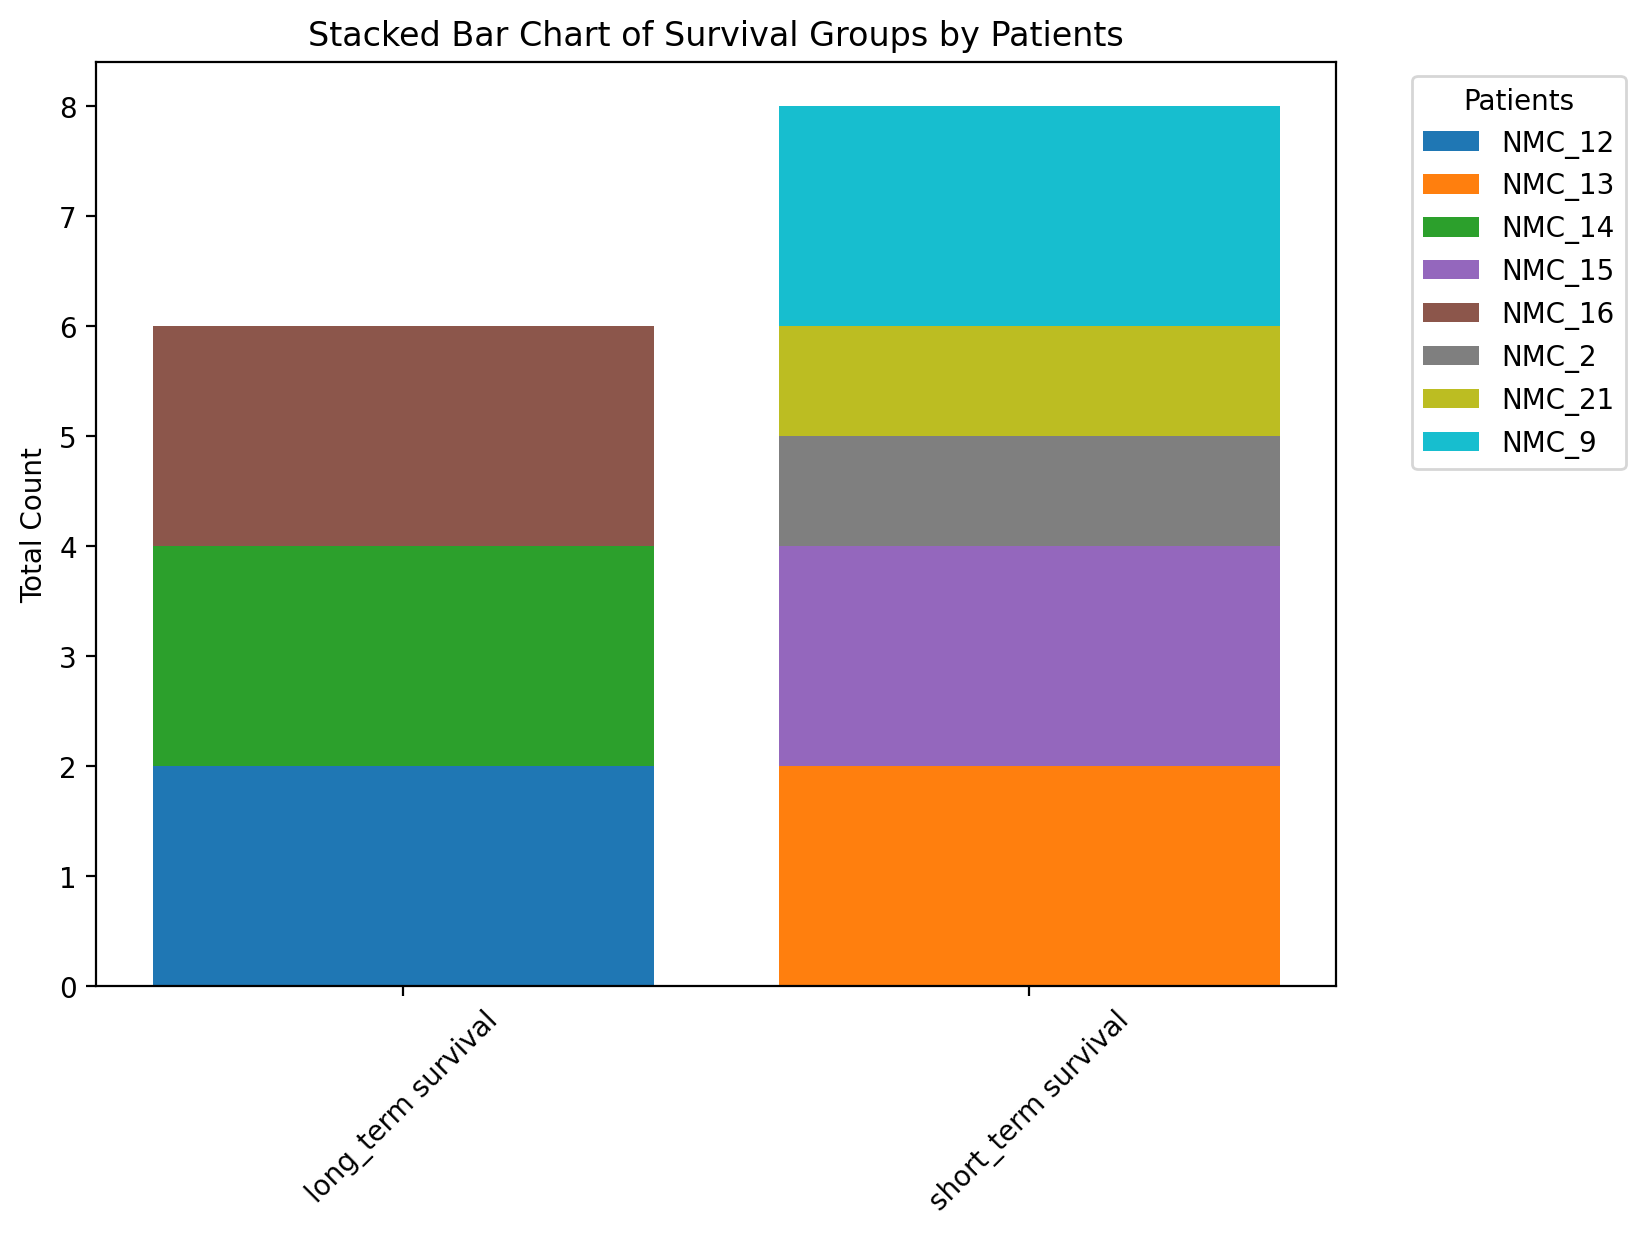

In [11]:
#barchart based on the outcome_group total number, divided by patients.
outcome_group_count = patients_metadata.groupby(['outcome_group', "patient_ID"]).size().reset_index(name='count')
outcome_group_count
pivot_df = outcome_group_count.pivot(index="patient_ID", columns="outcome_group", values="count").fillna(0)

#/ Get unique survival groups
survival_groups = pivot_df.columns

# Initialize figure
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors for different patients
colors = plt.cm.tab10(np.linspace(0, 1, len(pivot_df)))  # Get distinct colors

# Stack the bars for each survival group
bottoms = {group: np.zeros(len(survival_groups)) for group in survival_groups}

for i, patient in enumerate(pivot_df.index):
    values = pivot_df.loc[patient]
    ax.bar(survival_groups, values, label=patient, bottom=bottoms[survival_groups[0]], color=colors[i])
    bottoms[survival_groups[0]] += values

# Labels & legend
ax.set_ylabel("Total Count")
ax.set_title("Stacked Bar Chart of Survival Groups by Patients")
ax.legend(title="Patients", bbox_to_anchor=(1.05, 1), loc="upper left")  # Move legend outside

plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


# Check the Cell type Distribution

## Remove the trash cells

In [12]:
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    meta = pd.read_csv(roi / 'metadata.csv')
    meta = meta.loc[meta["cell_type"] != "Trash"]
    exp = exp[exp["cell_id"].isin(meta.cell_id)]
    #export csvs
    exp.to_csv(roi / 'exp.csv', index=False)
    meta.to_csv(roi / 'metadata.csv', index=False)

## Extract the names of all cell types

In [13]:
# Create a list of all cell types
all_cell_types = []  
for i, roi in enumerate(roi_list):
    meta = pd.read_csv(roi / 'metadata.csv')
    all_cell_types.extend(meta["cell_type"].unique())
# Create a set of unique cell types
all_cell_types = sorted(set(all_cell_types))   
# Create a DataFrame with all cell types and initialize counts to zero
meta = pd.read_csv(roi_list[0] / 'metadata.csv')
meta_counts = meta["cell_type"].value_counts()
for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
sorted_order = meta_counts.index  # Extract the index order from a reference DataFrame
all_cell_types = list(sorted_order)
all_cell_types

['Tumor_cells',
 'Actin+_cells',
 'NFC',
 'Endothelial_cells',
 'CD4+_T_cells',
 'M1_macrophages',
 'DCs',
 'M1_M2_macrophages',
 'Mast_cells',
 'M2_macrophages',
 'CD8+_T_cells',
 'Treg_T_cells',
 'Plasma_cells',
 'Lymphatic_endothelial_cells',
 'MDSCs',
 'B_cells',
 'Granulocytes',
 'Epithelial_cells',
 'NK_cells']

## Plot cell types distribution

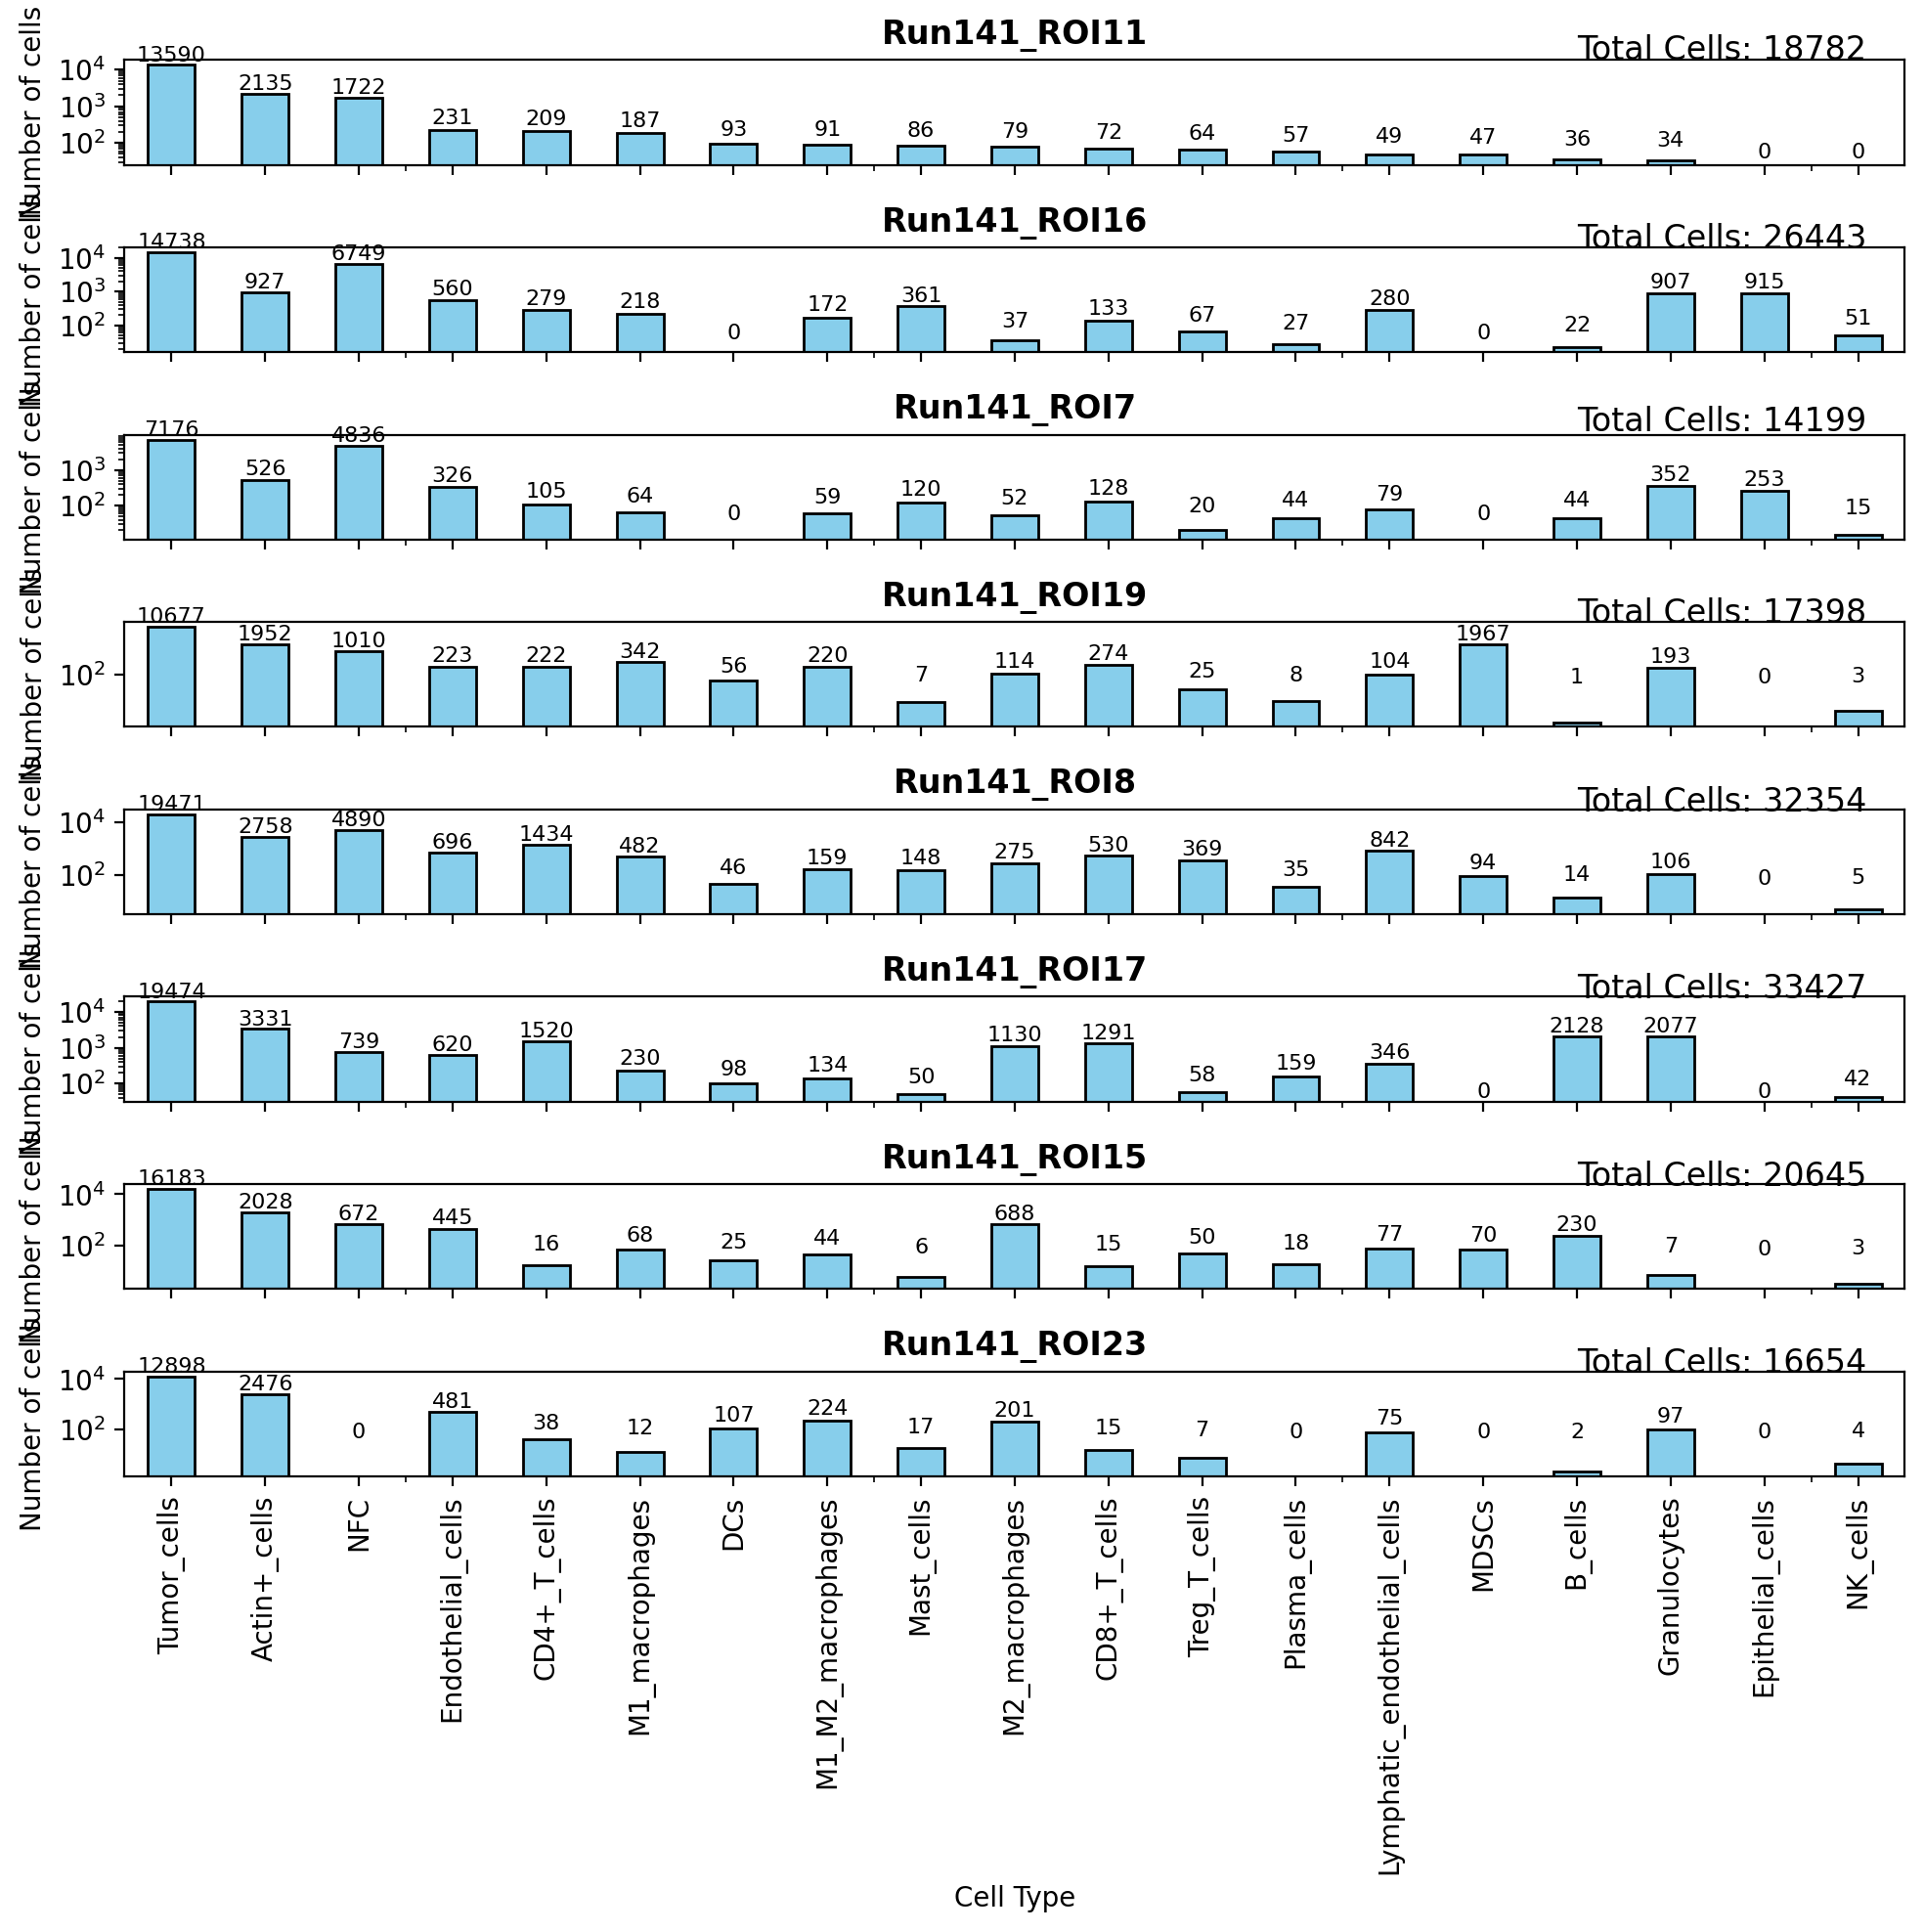

In [14]:
fig, axes = plt.subplots(len(roi_list), 1, figsize=(10, 10), sharex=True)

for i, roi in enumerate(roi_list):
    meta = pd.read_csv(roi / 'metadata.csv')
    meta_counts = meta["cell_type"].value_counts()
    #fill cell types with 0 if they are not present in the metadata
    for cell_type in all_cell_types:
        if cell_type not in meta_counts:
            meta_counts[cell_type] = 0
    meta_counts = meta_counts.reindex(all_cell_types)
    meta_counts.plot(kind='bar', ax=axes[i], color = "skyblue", edgecolor='black')
    axes[i].text(15, np.max(meta_counts) + 5000 , f'Total Cells: {meta_counts.sum()}', fontsize=12)
    #add the number of cells in each cell type on the bar
    for j, count in enumerate(meta_counts):
        axes[i].text(j, count + 30, count, ha='center', va='bottom', fontsize=8)
    axes[i].set_title(roi.name, fontweight='bold')
    axes[i].set_ylabel('Number of cells')
    #log transform the y-axis
    axes[i].set_yscale('log')

axes[-1].set_xticks(range(len(all_cell_types)))
axes[-1].set_xticklabels(all_cell_types, rotation=90)
axes[i].set_xlabel("Cell Type")

fig.tight_layout()

# Antibodies QC

## Load the antibody panel 

In [15]:
#Read the antibodies list
antibodies = pd.read_excel(metadata_dir/"Run141_Ab_panel.xlsx", sheet_name=["IO core panel", "Add-on Panel"])
#Concatenate the two sheets
antibodies = pd.concat(antibodies, ignore_index=True)
#Fix the column names
antibodies["ab_clone"] = antibodies["ab_clone"].str.replace("__", " ")
antibodies["ab_clone"] = antibodies["ab_clone"].str.replace("_", " ")
antibodies[antibodies.duplicated(subset='ab_clone')] = antibodies[antibodies.duplicated(subset='ab_clone')].astype(str).apply(lambda x: x + " 1")

/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_18928/2474731241.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['4.0 1' '6.0 1' '15.0 1' '18.0 1' '25.0 1' 'nan 1']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  antibodies[antibodies.duplicated(subset='ab_clone')] = antibodies[antibodies.duplicated(subset='ab_clone')].astype(str).apply(lambda x: x + " 1")


## Remove the antibodies with low staining quality

In [16]:
low_antibodies = antibodies[antibodies["staining quality"] == "LOW"].ab_clone
medium_antibodies = antibodies[antibodies["staining quality"] == "MEDIUM"].ab_clone

In [17]:
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    exp.drop(columns=low_antibodies, inplace=True)
    exp.to_csv(roi / 'exp.csv', index=False)

## Plot the raw antibodies expression 

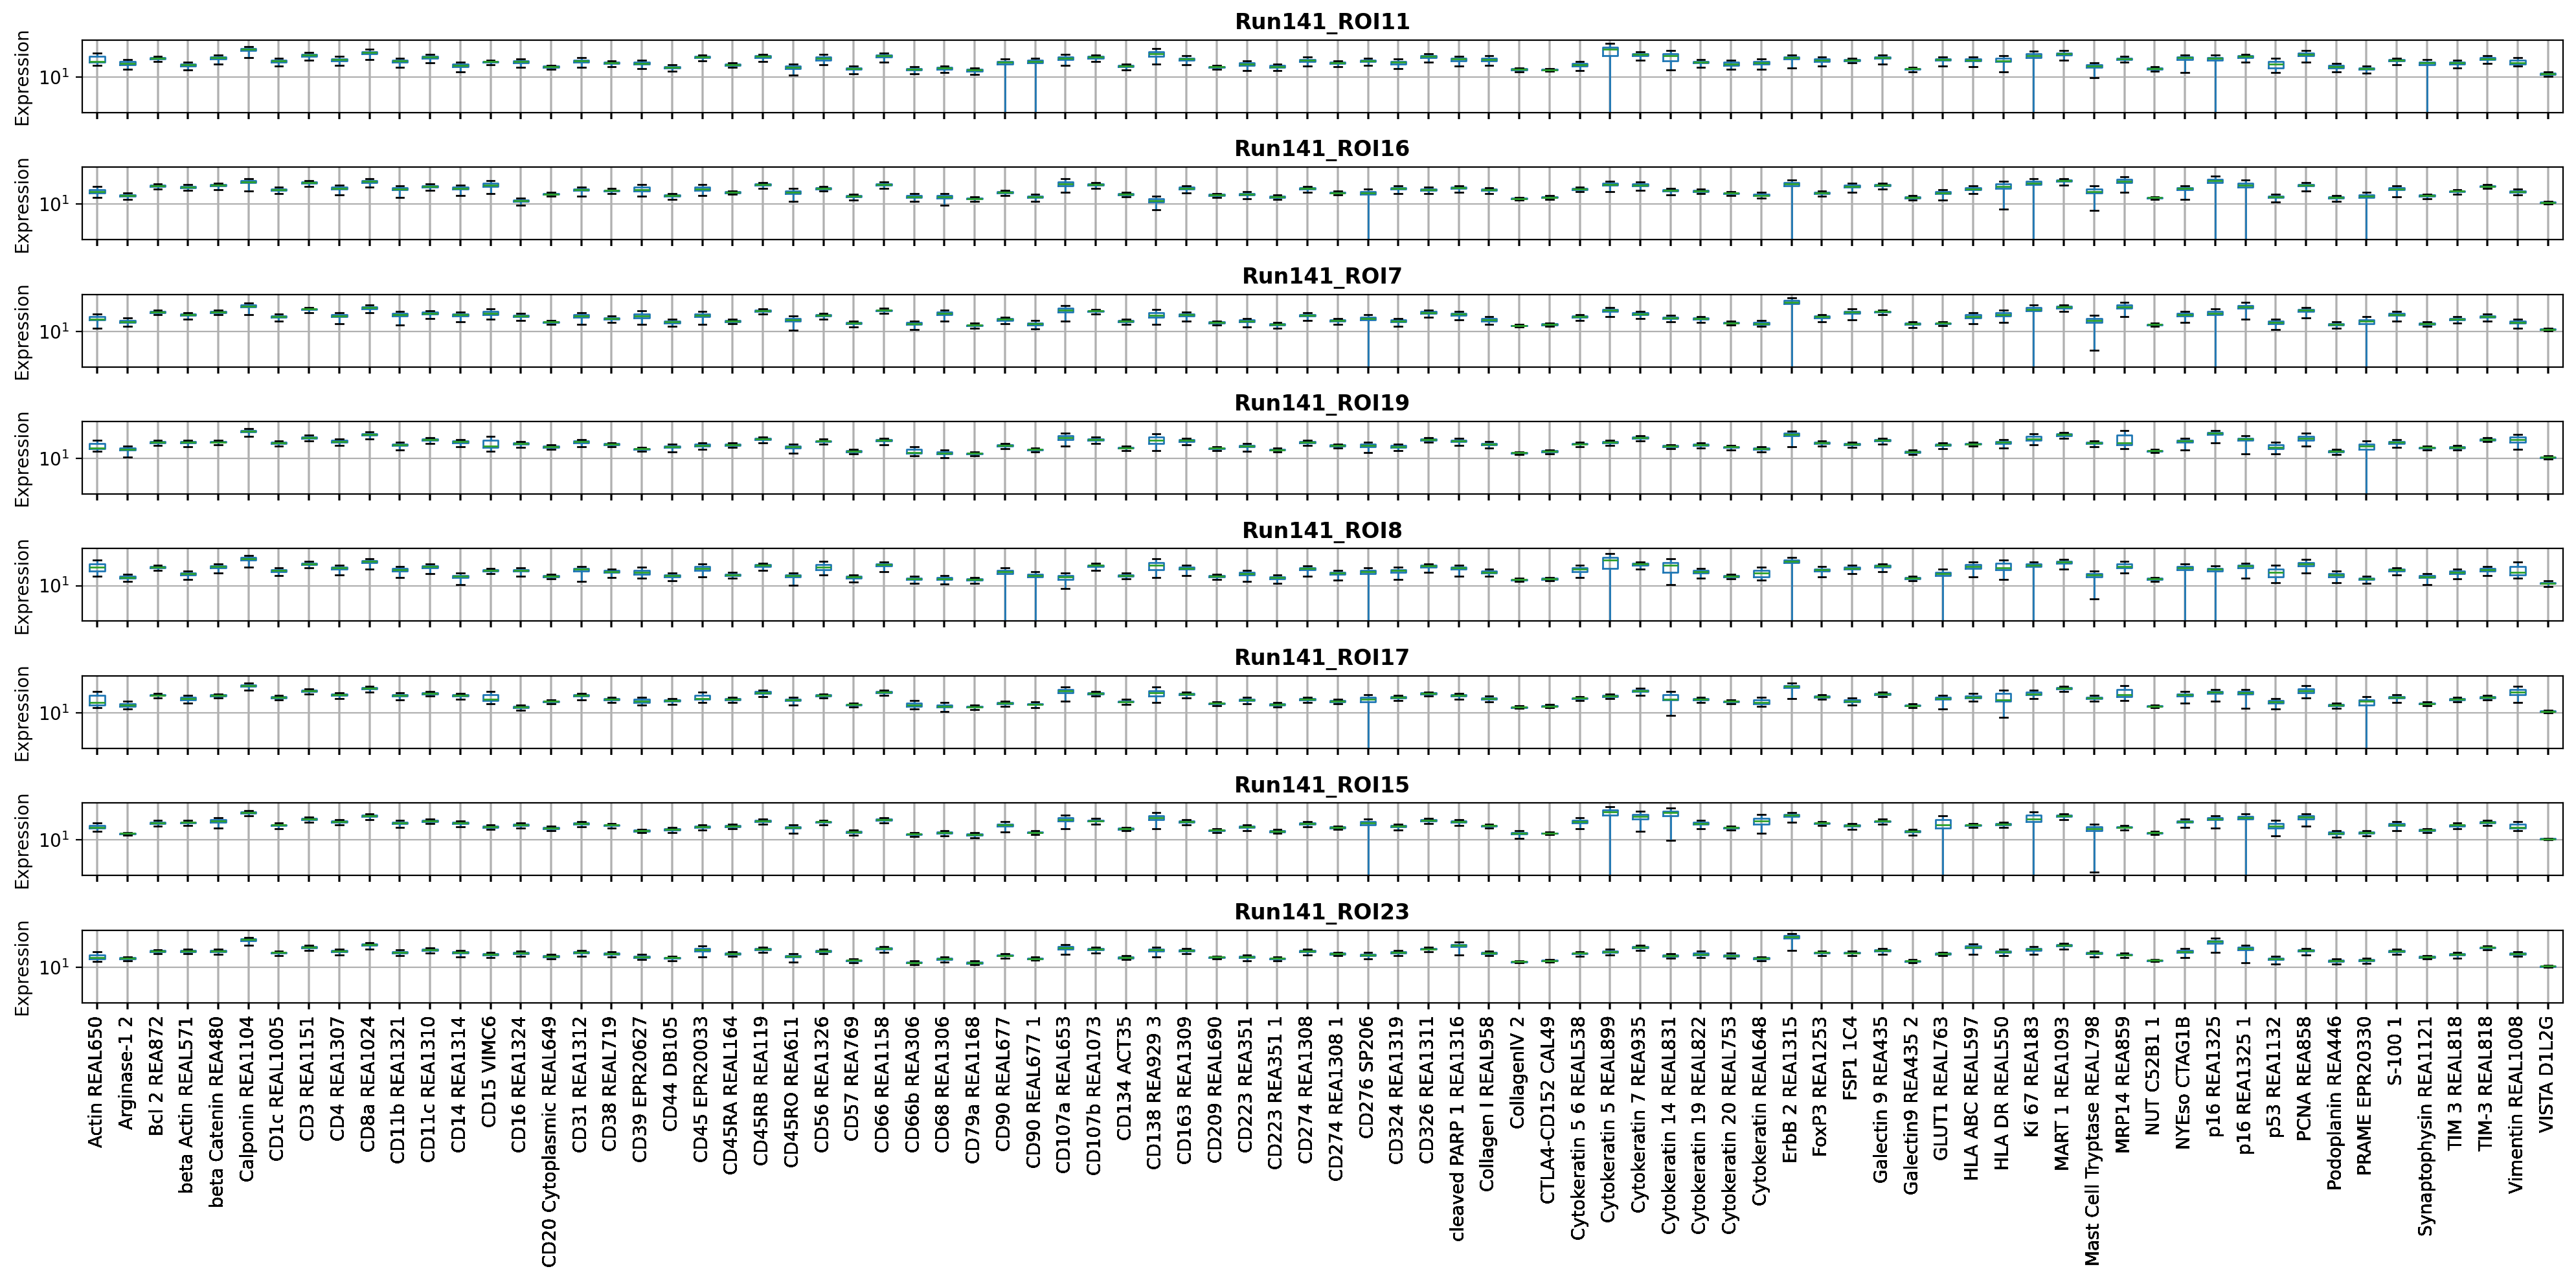

In [18]:
fig, axes = plt.subplots(len(roi_list), 1, figsize=(20, 10), sharex=True, sharey=True)

for i, roi in enumerate(roi_list):
    exp = pd.read_csv(roi / 'exp.csv')

    exp.iloc[:,1:].boxplot(ax=axes[i], rot=90, showfliers=False)
    axes[i].set_title(roi.name, fontweight='bold')
    axes[i].set_ylabel('Expression')
    axes[i].set_yscale('log')

fig.tight_layout()

## Plotting the histograms of the lowly expressed markers

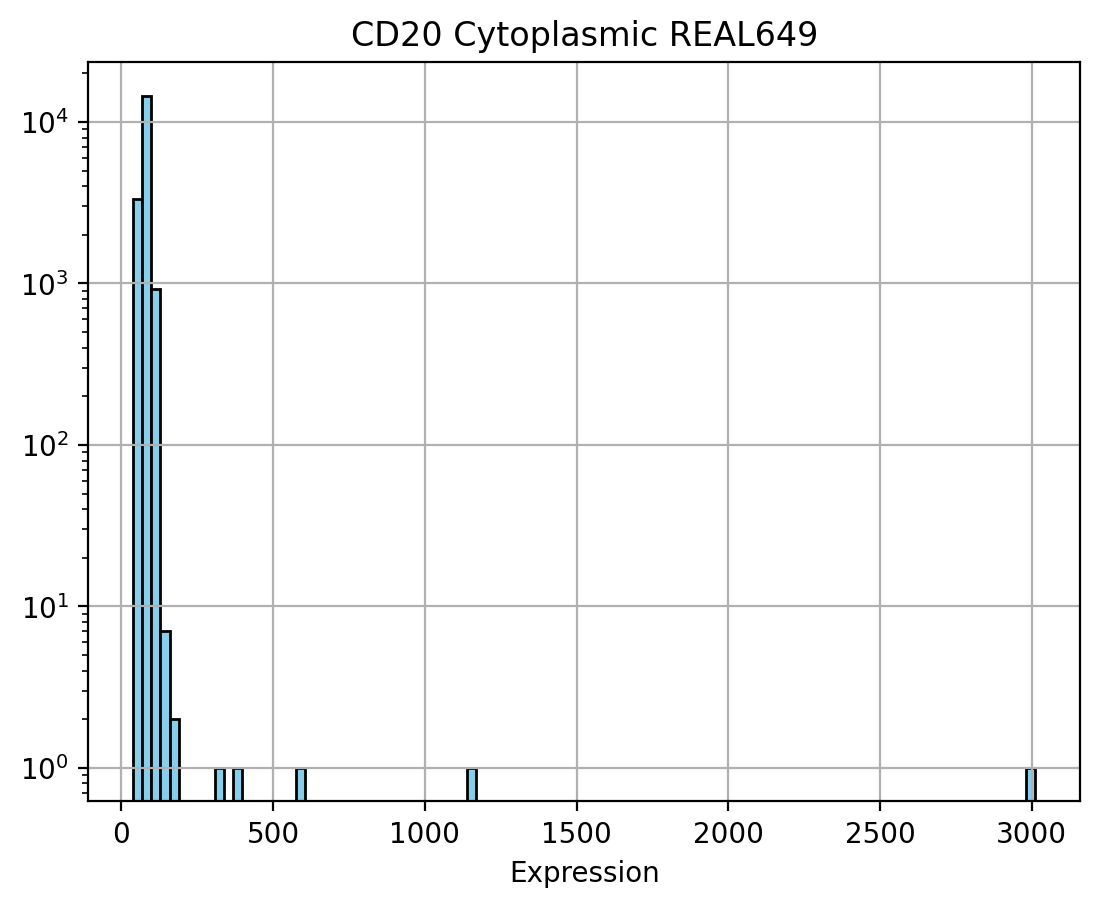

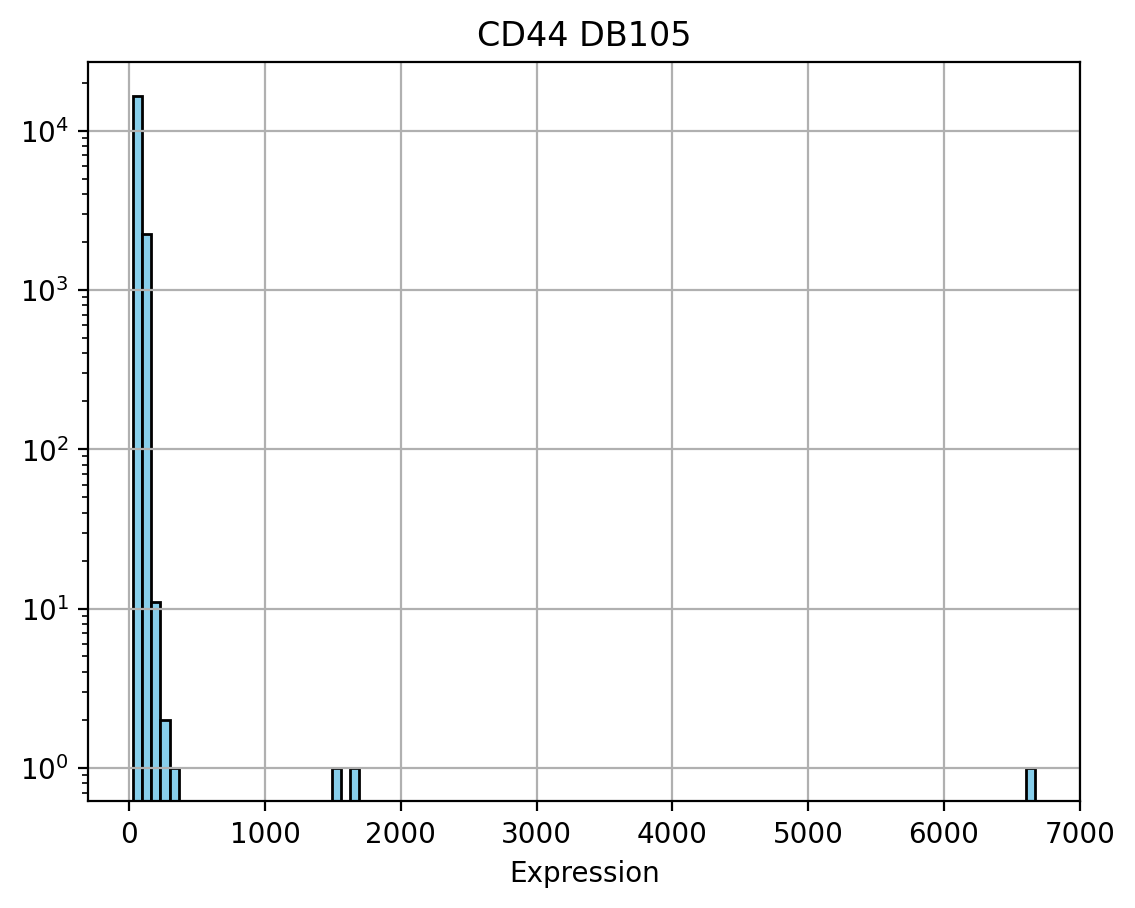

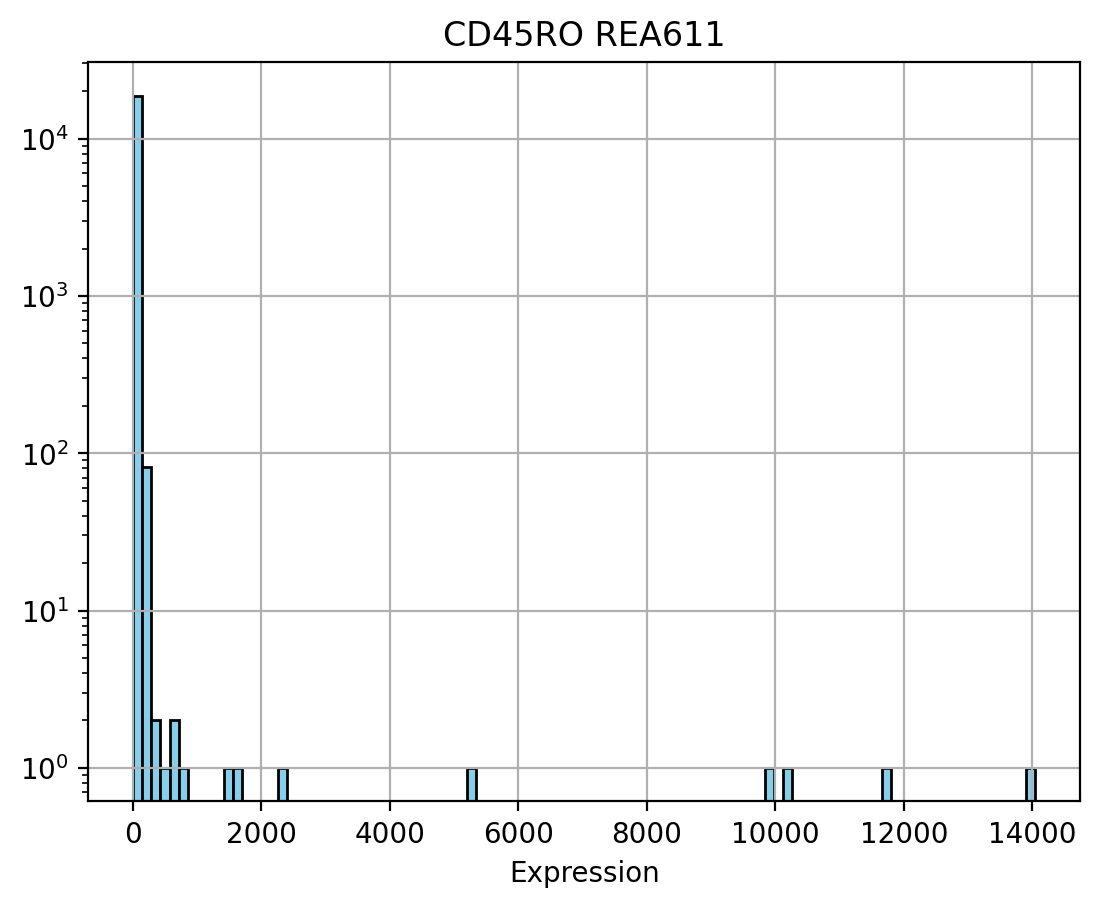

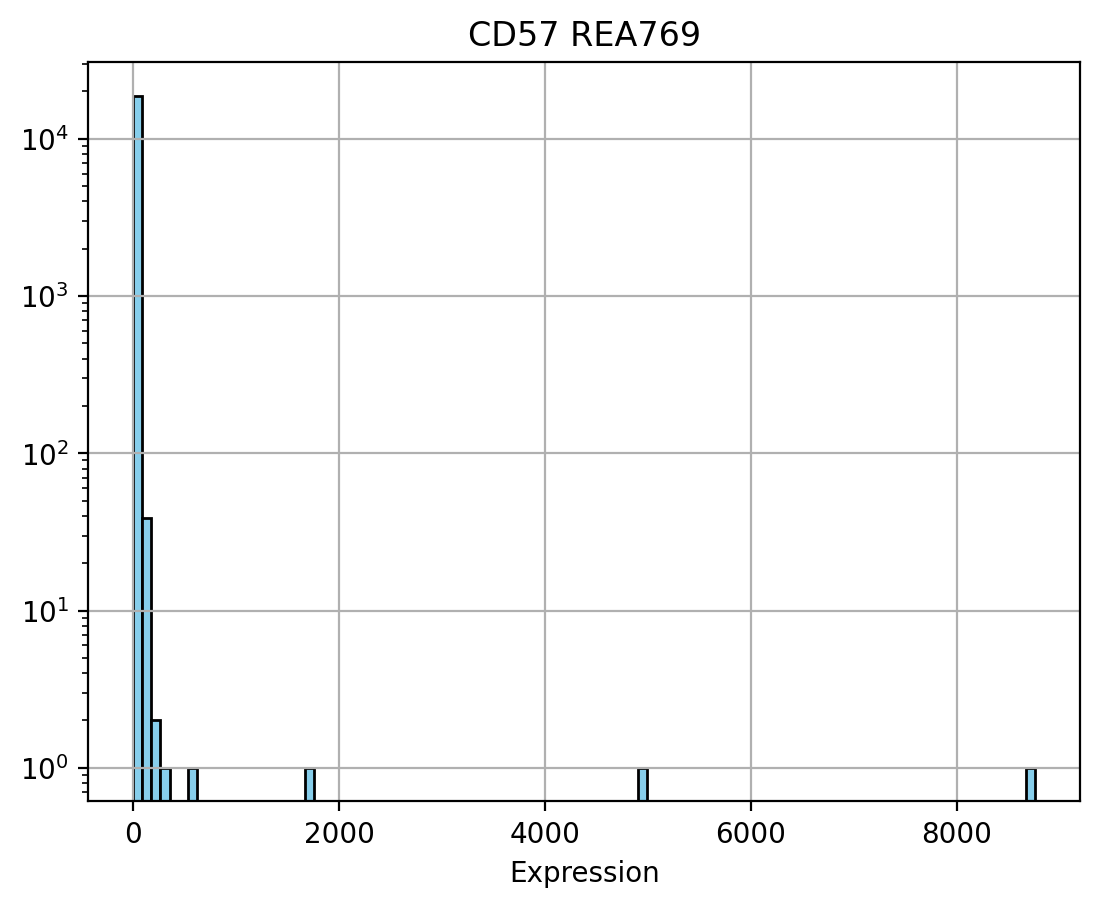

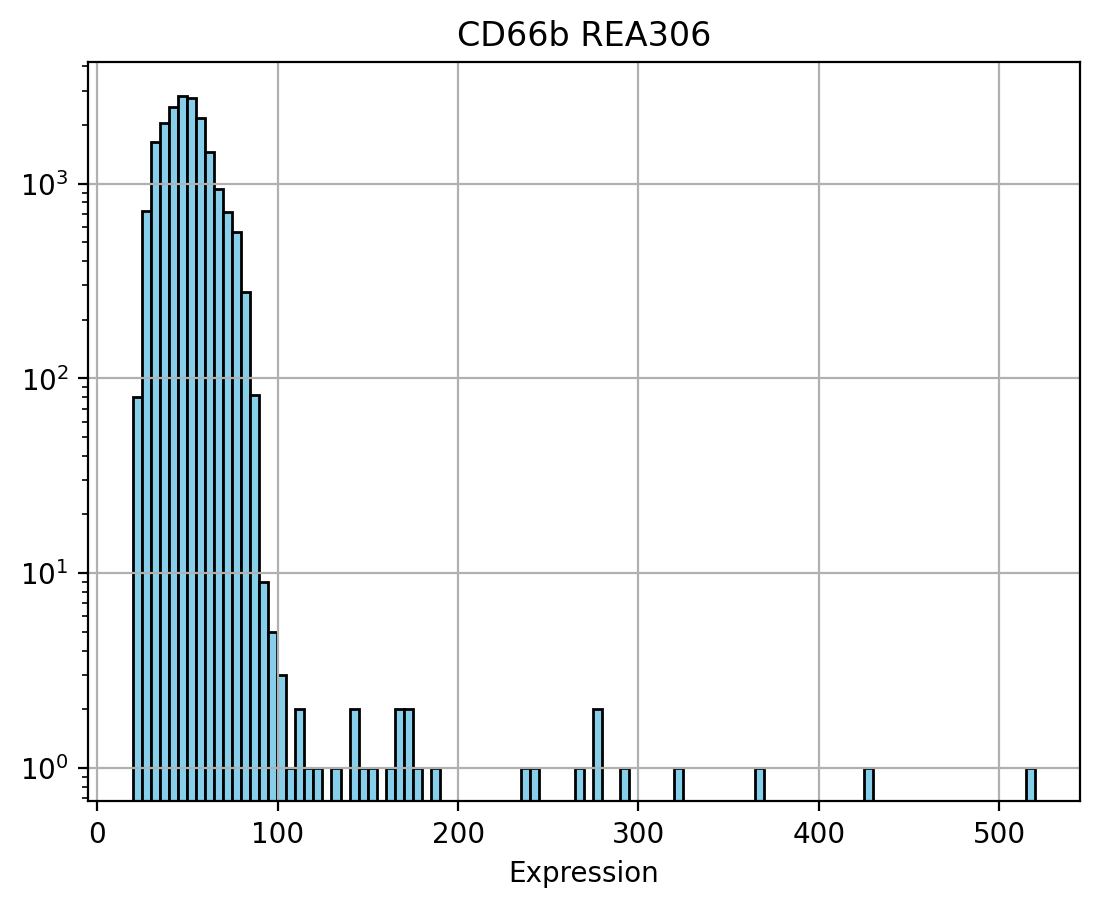

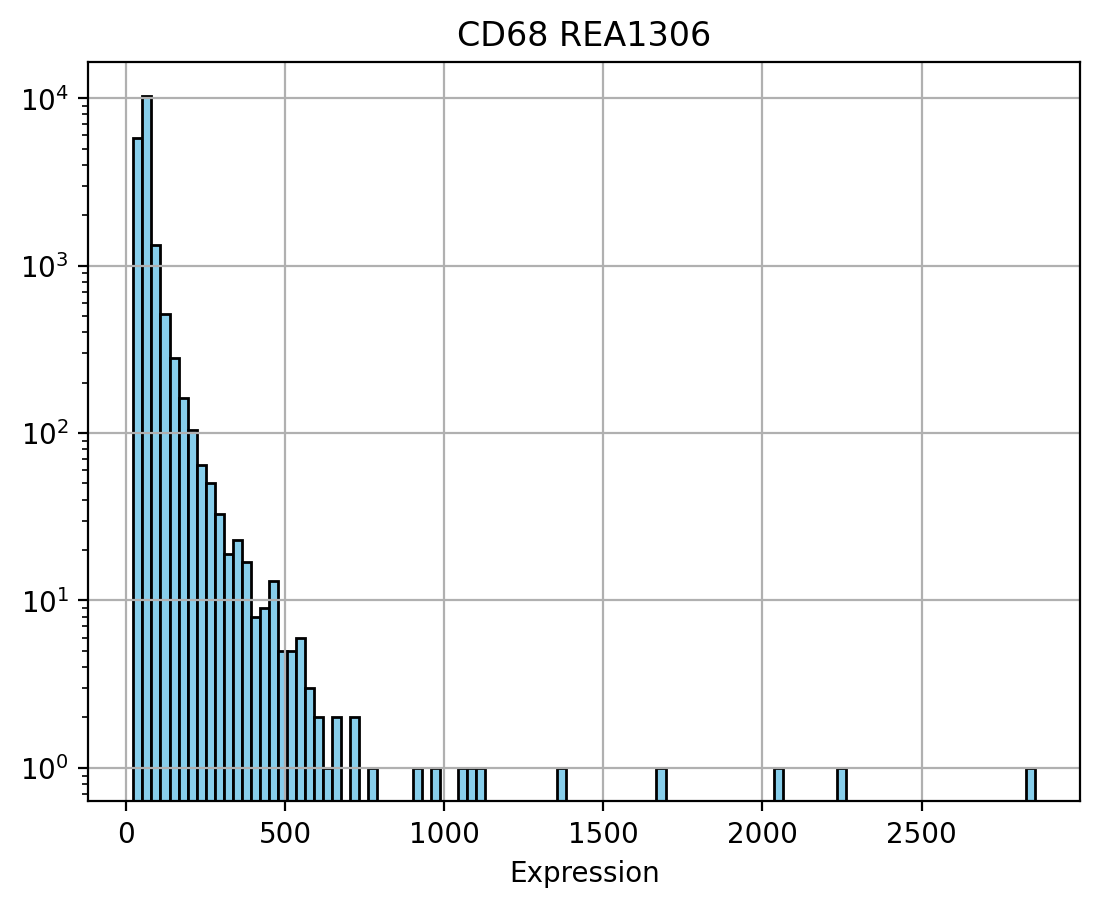

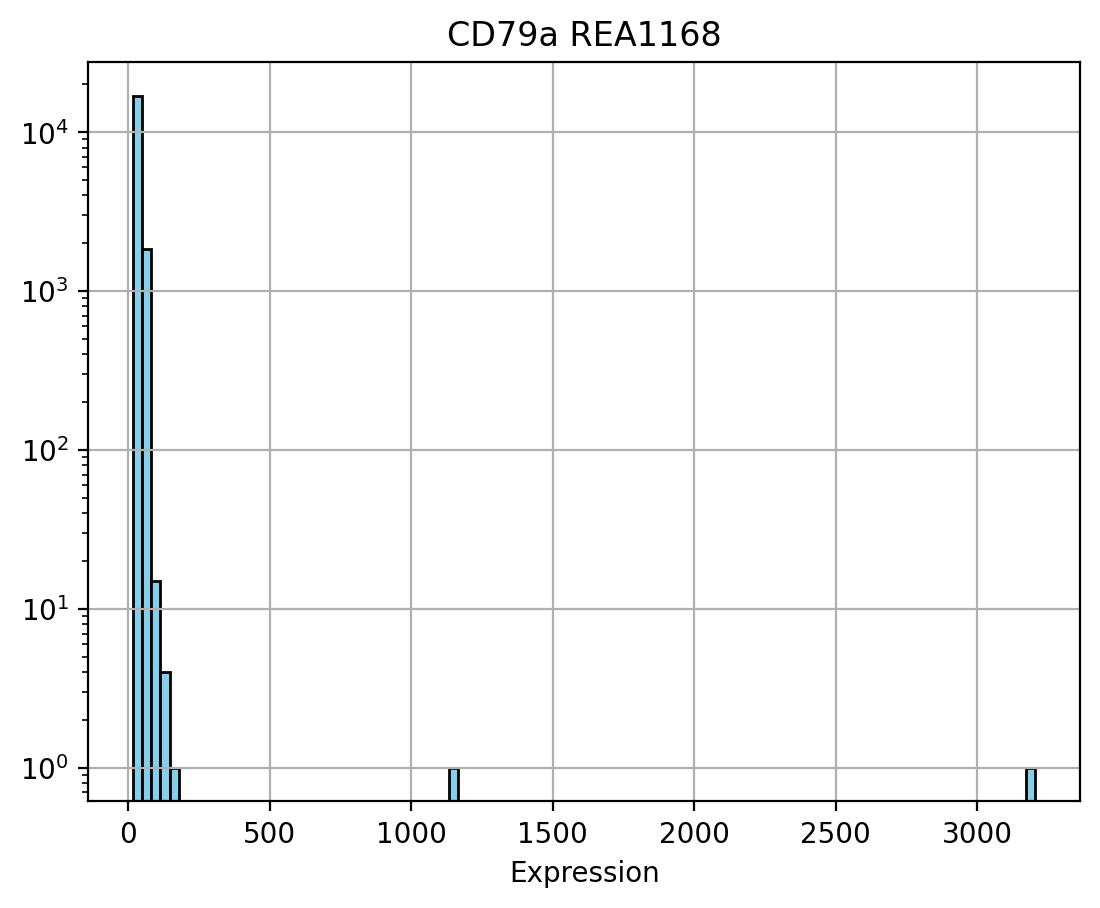

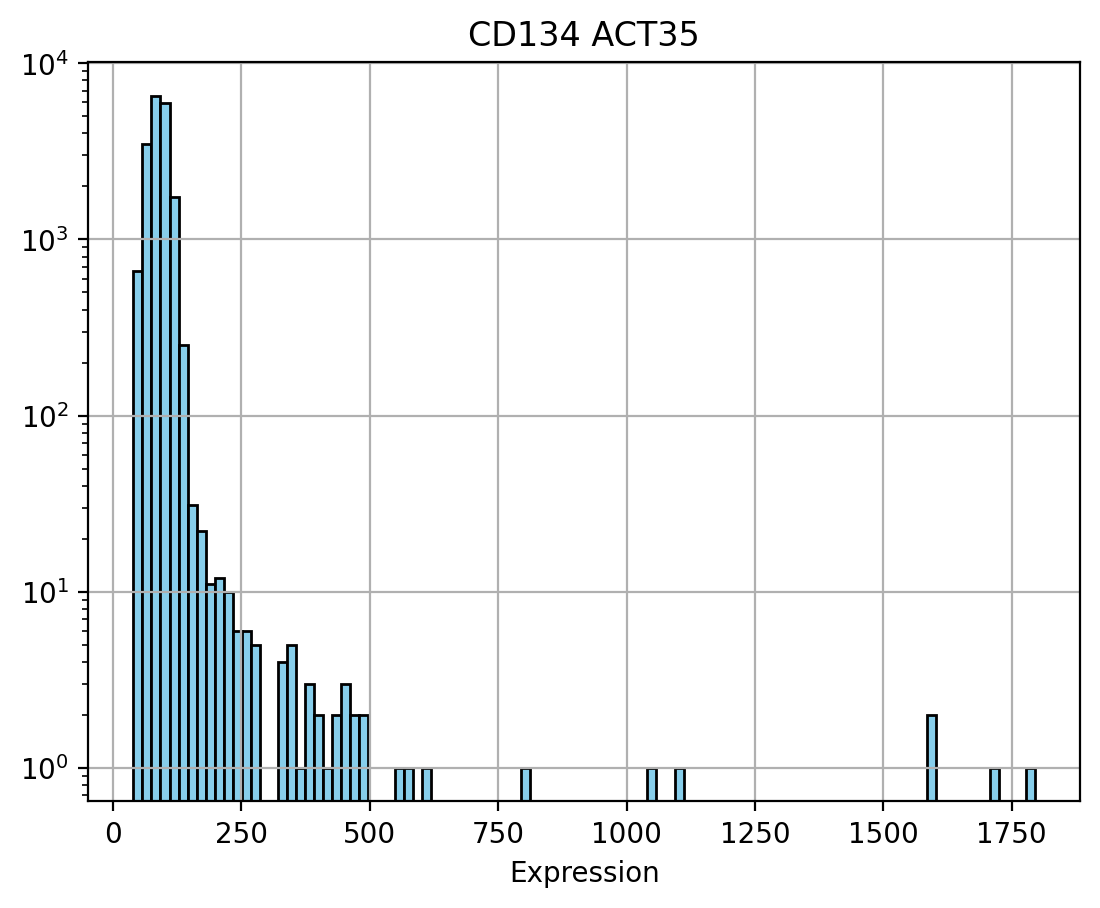

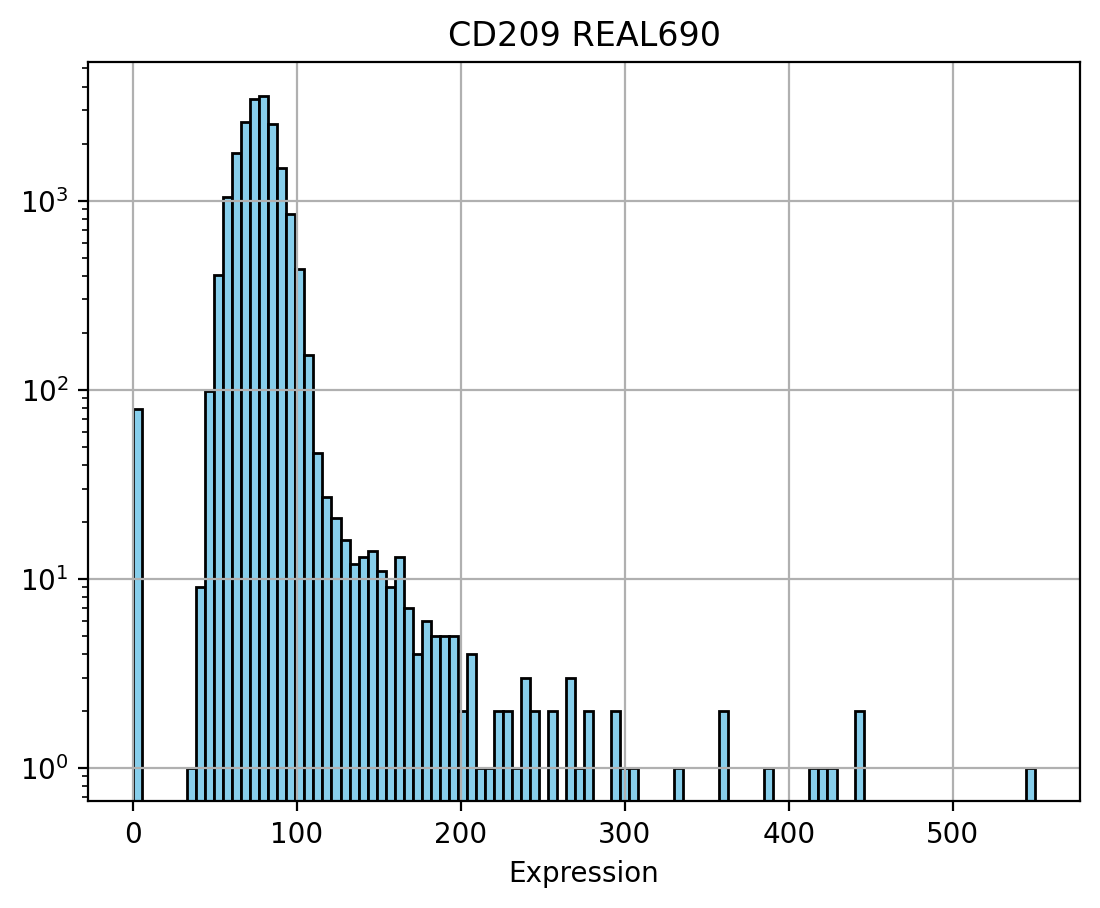

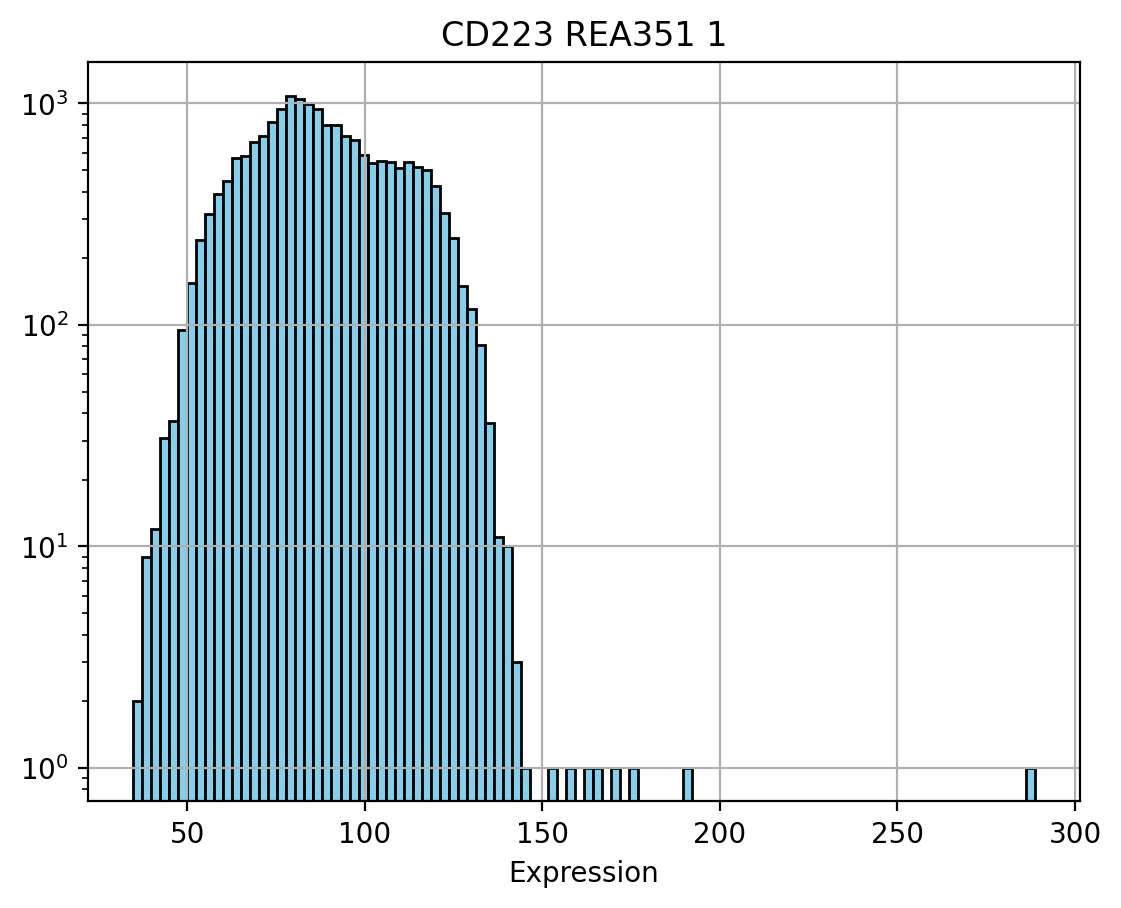

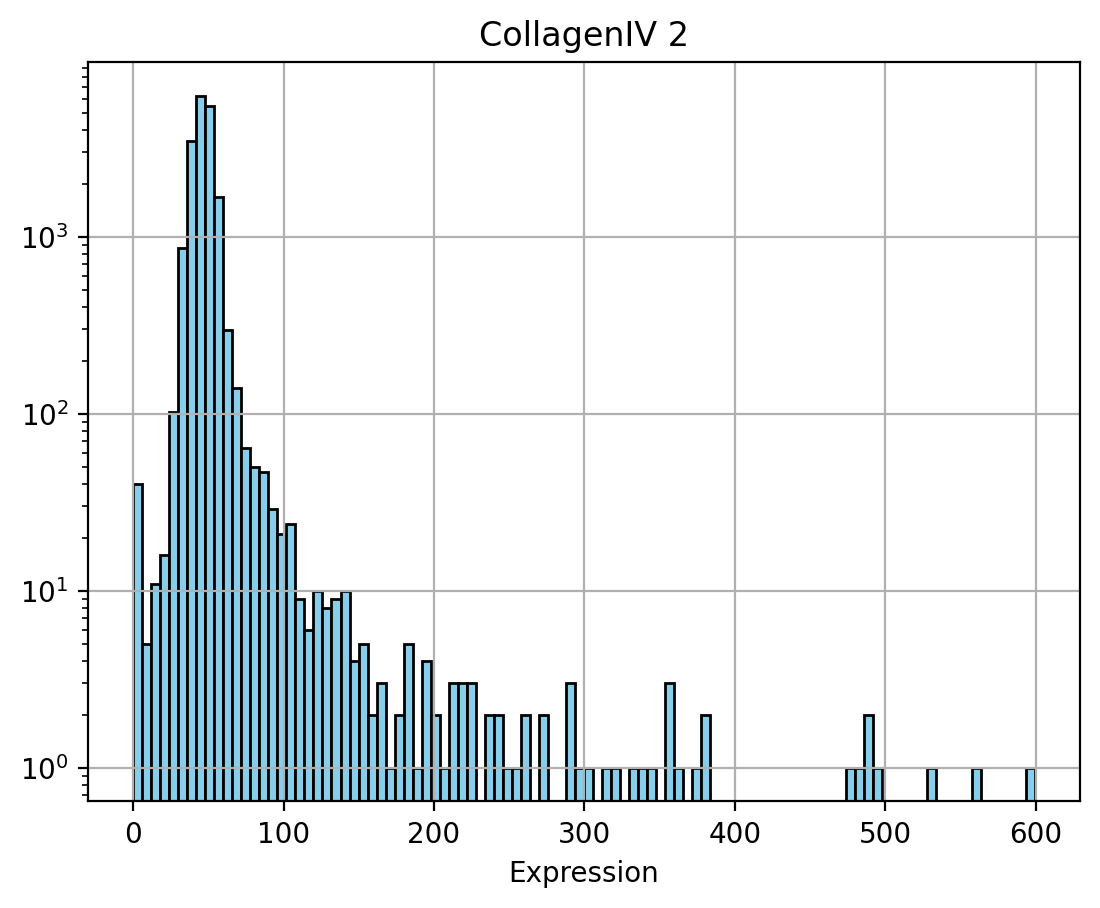

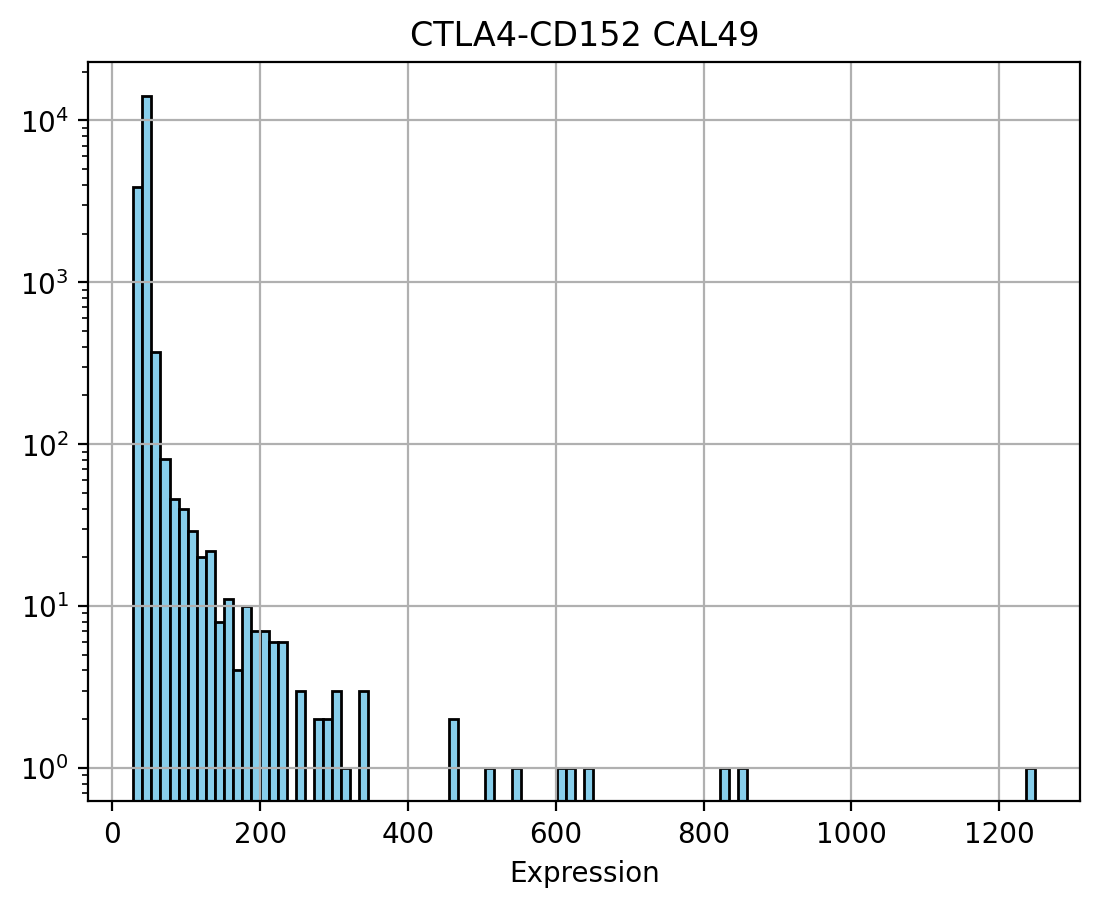

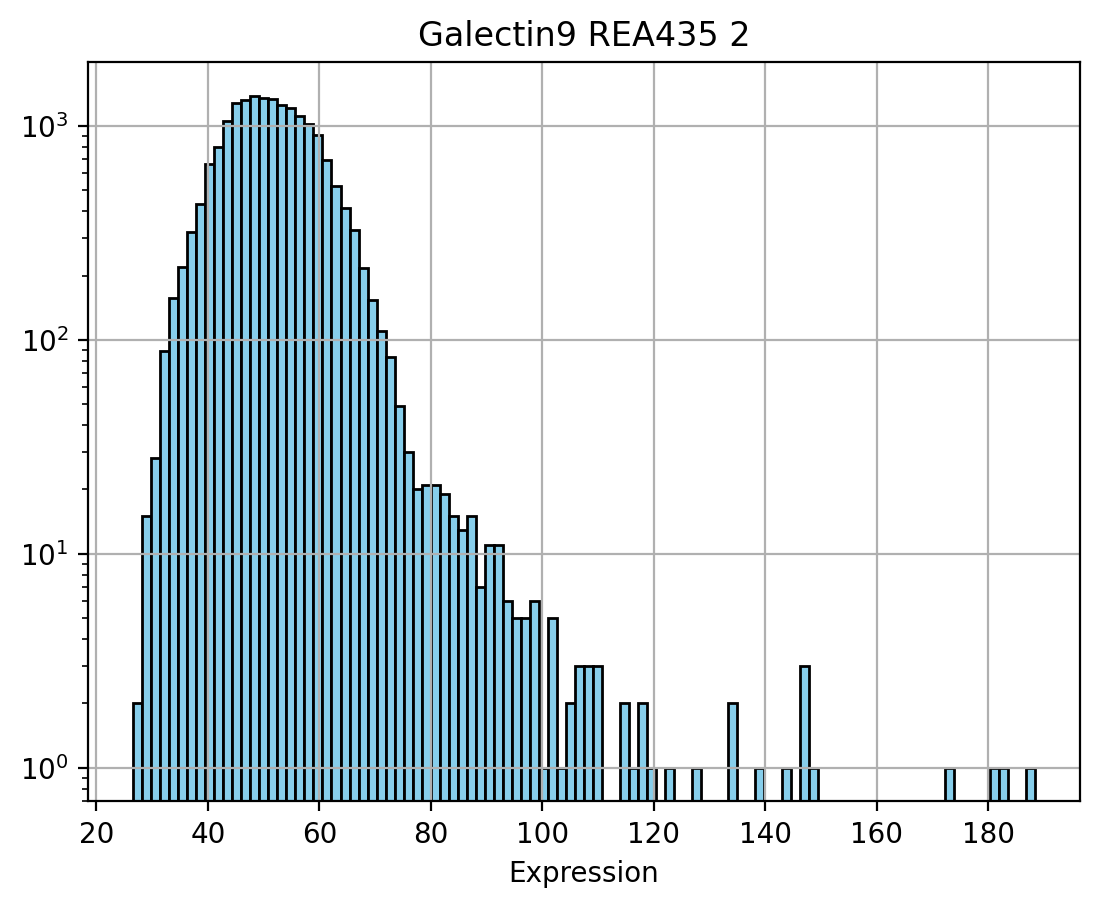

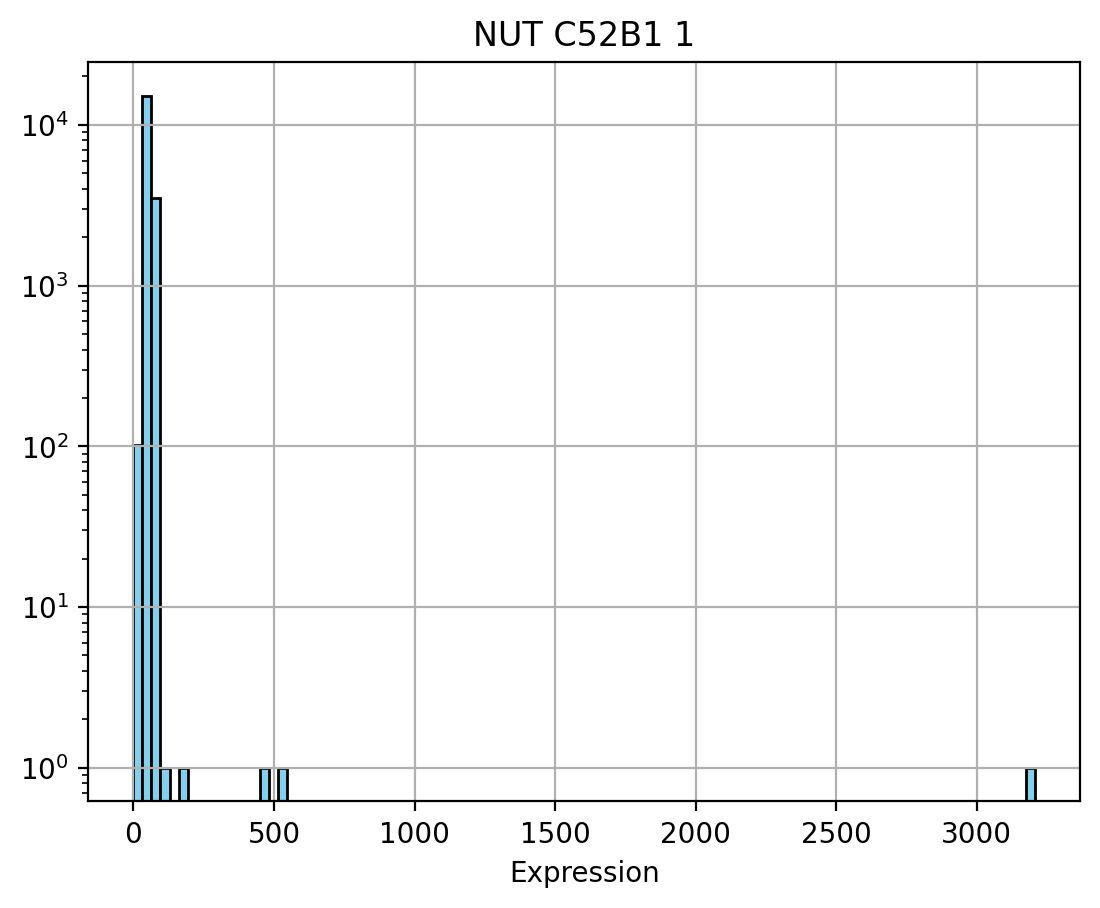

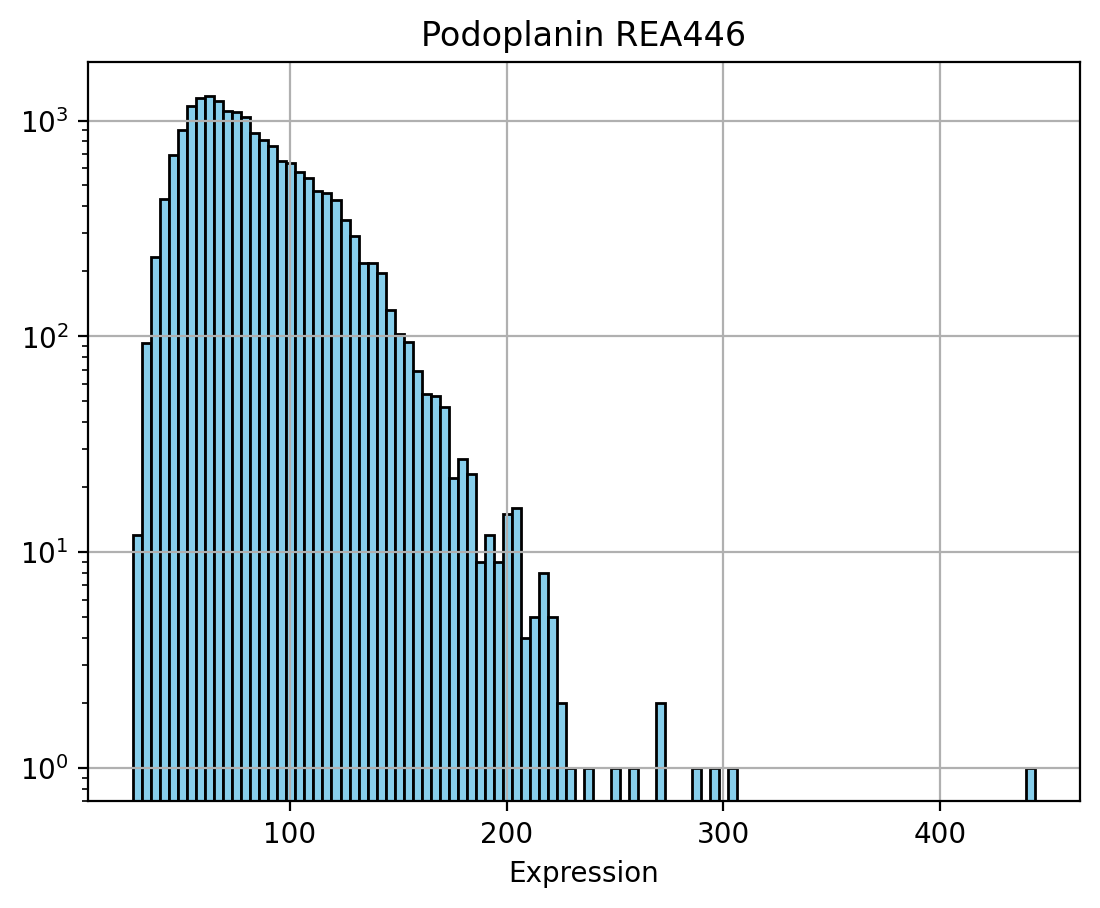

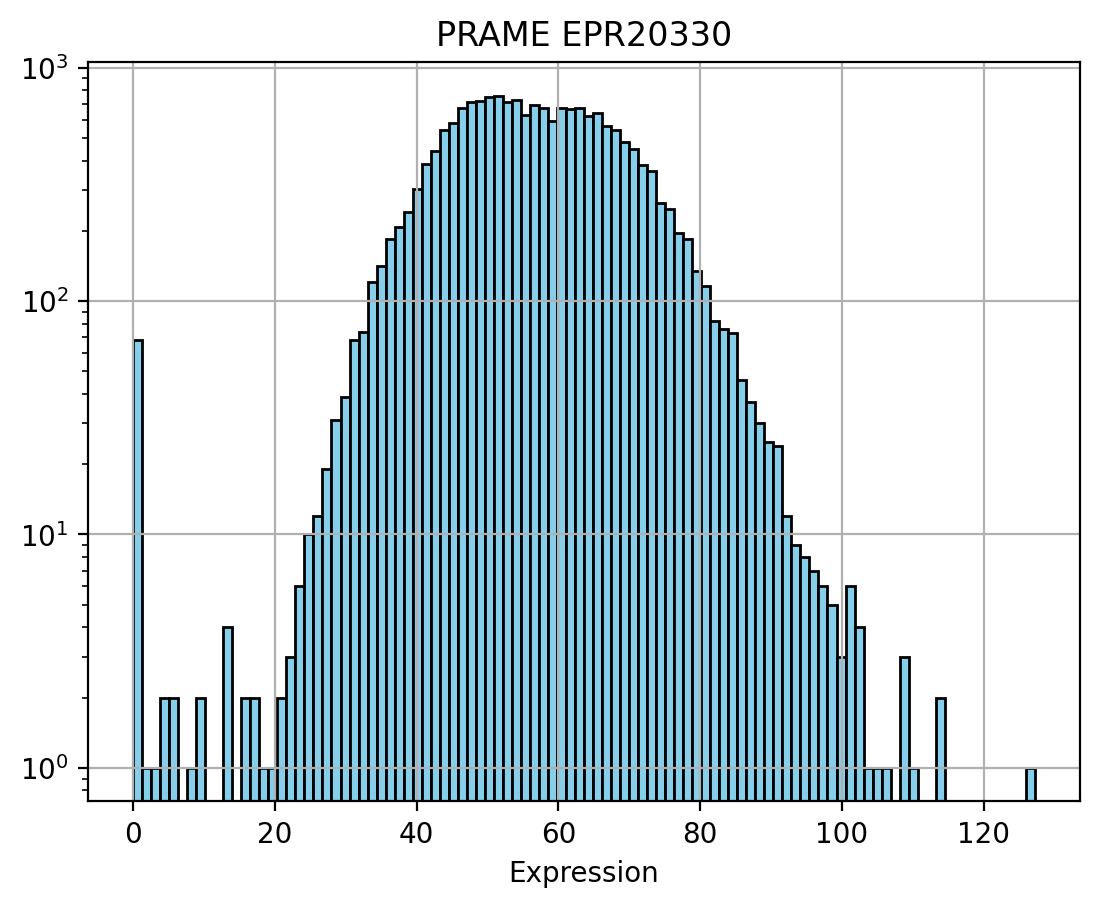

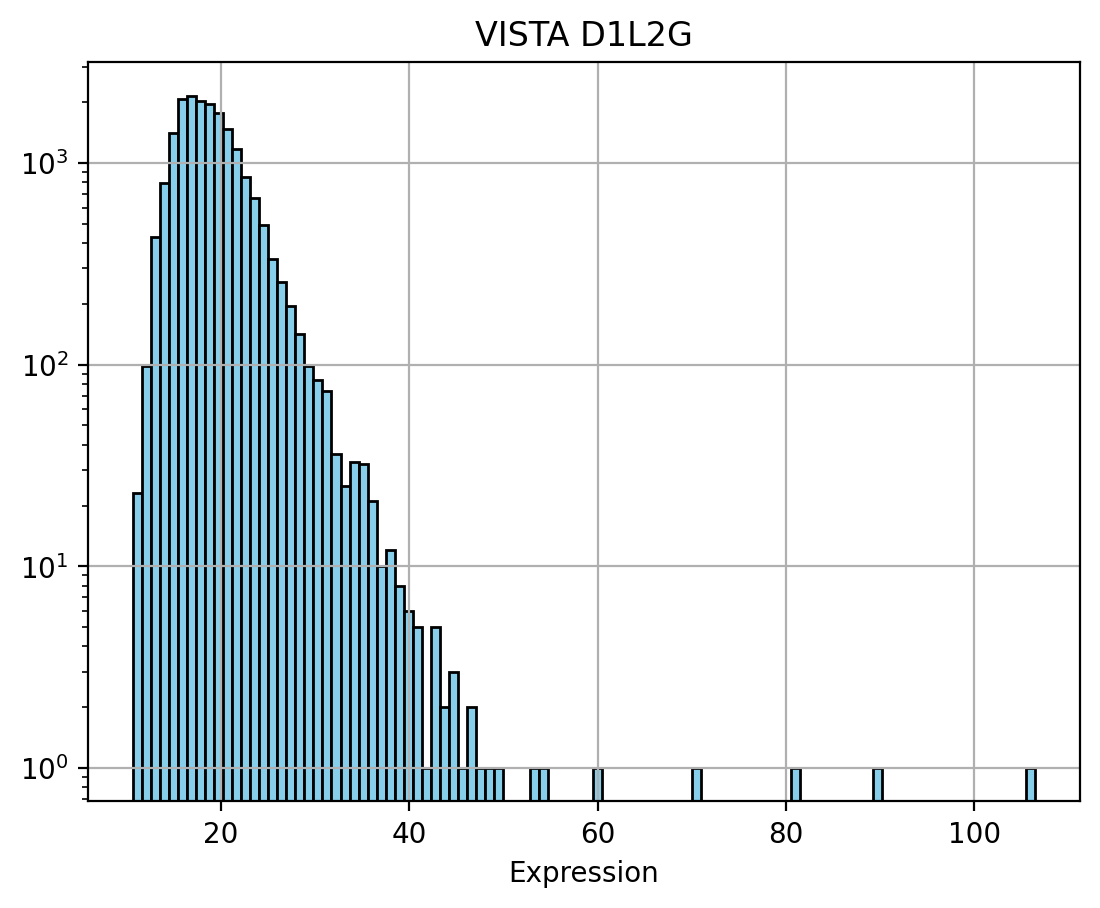

In [19]:
#calculate mean of all columns in exp
exp = pd.read_csv(roi_list[0] / 'exp.csv')
avg = exp.iloc[:,1:].mean(skipna=True)
avg = avg[avg < 100]

low_antibodies = avg.index

for marker in low_antibodies:
    exp[marker].hist(bins=100, color='skyblue', edgecolor='black', log=True)
    plt.title(marker)
    plt.xlabel('Expression')
    plt.show()

## Find duplicated antibodies (different dilutation factors)

In [20]:
duplicated_antibodies = pd.Series([antibody[:-2] for antibody in antibodies["ab_clone"] if antibody.endswith(" 1")])
duplicated_antibodies = duplicated_antibodies.to_numpy()
#add TIM
duplicated_antibodies = np.append(duplicated_antibodies, "TIM")
#remove S100
duplicated_antibodies = np.delete(duplicated_antibodies, np.where(duplicated_antibodies == "S-100"))
#remove NUT from the duplicated_antibodies
duplicated_antibodies = np.delete(duplicated_antibodies, np.where(duplicated_antibodies == "NUT C52B1"))
#remove CD279 
duplicated_antibodies = np.delete(duplicated_antibodies, np.where(duplicated_antibodies == "CD279 REA1165"))
duplicated_antibodies

array(['CD274 REA1308', 'CD223 REA351', 'CD90 REAL677', 'p16 REA1325',
       'TIM'], dtype=object)

## Plot the correlation between the antibody intensity and its diluted version

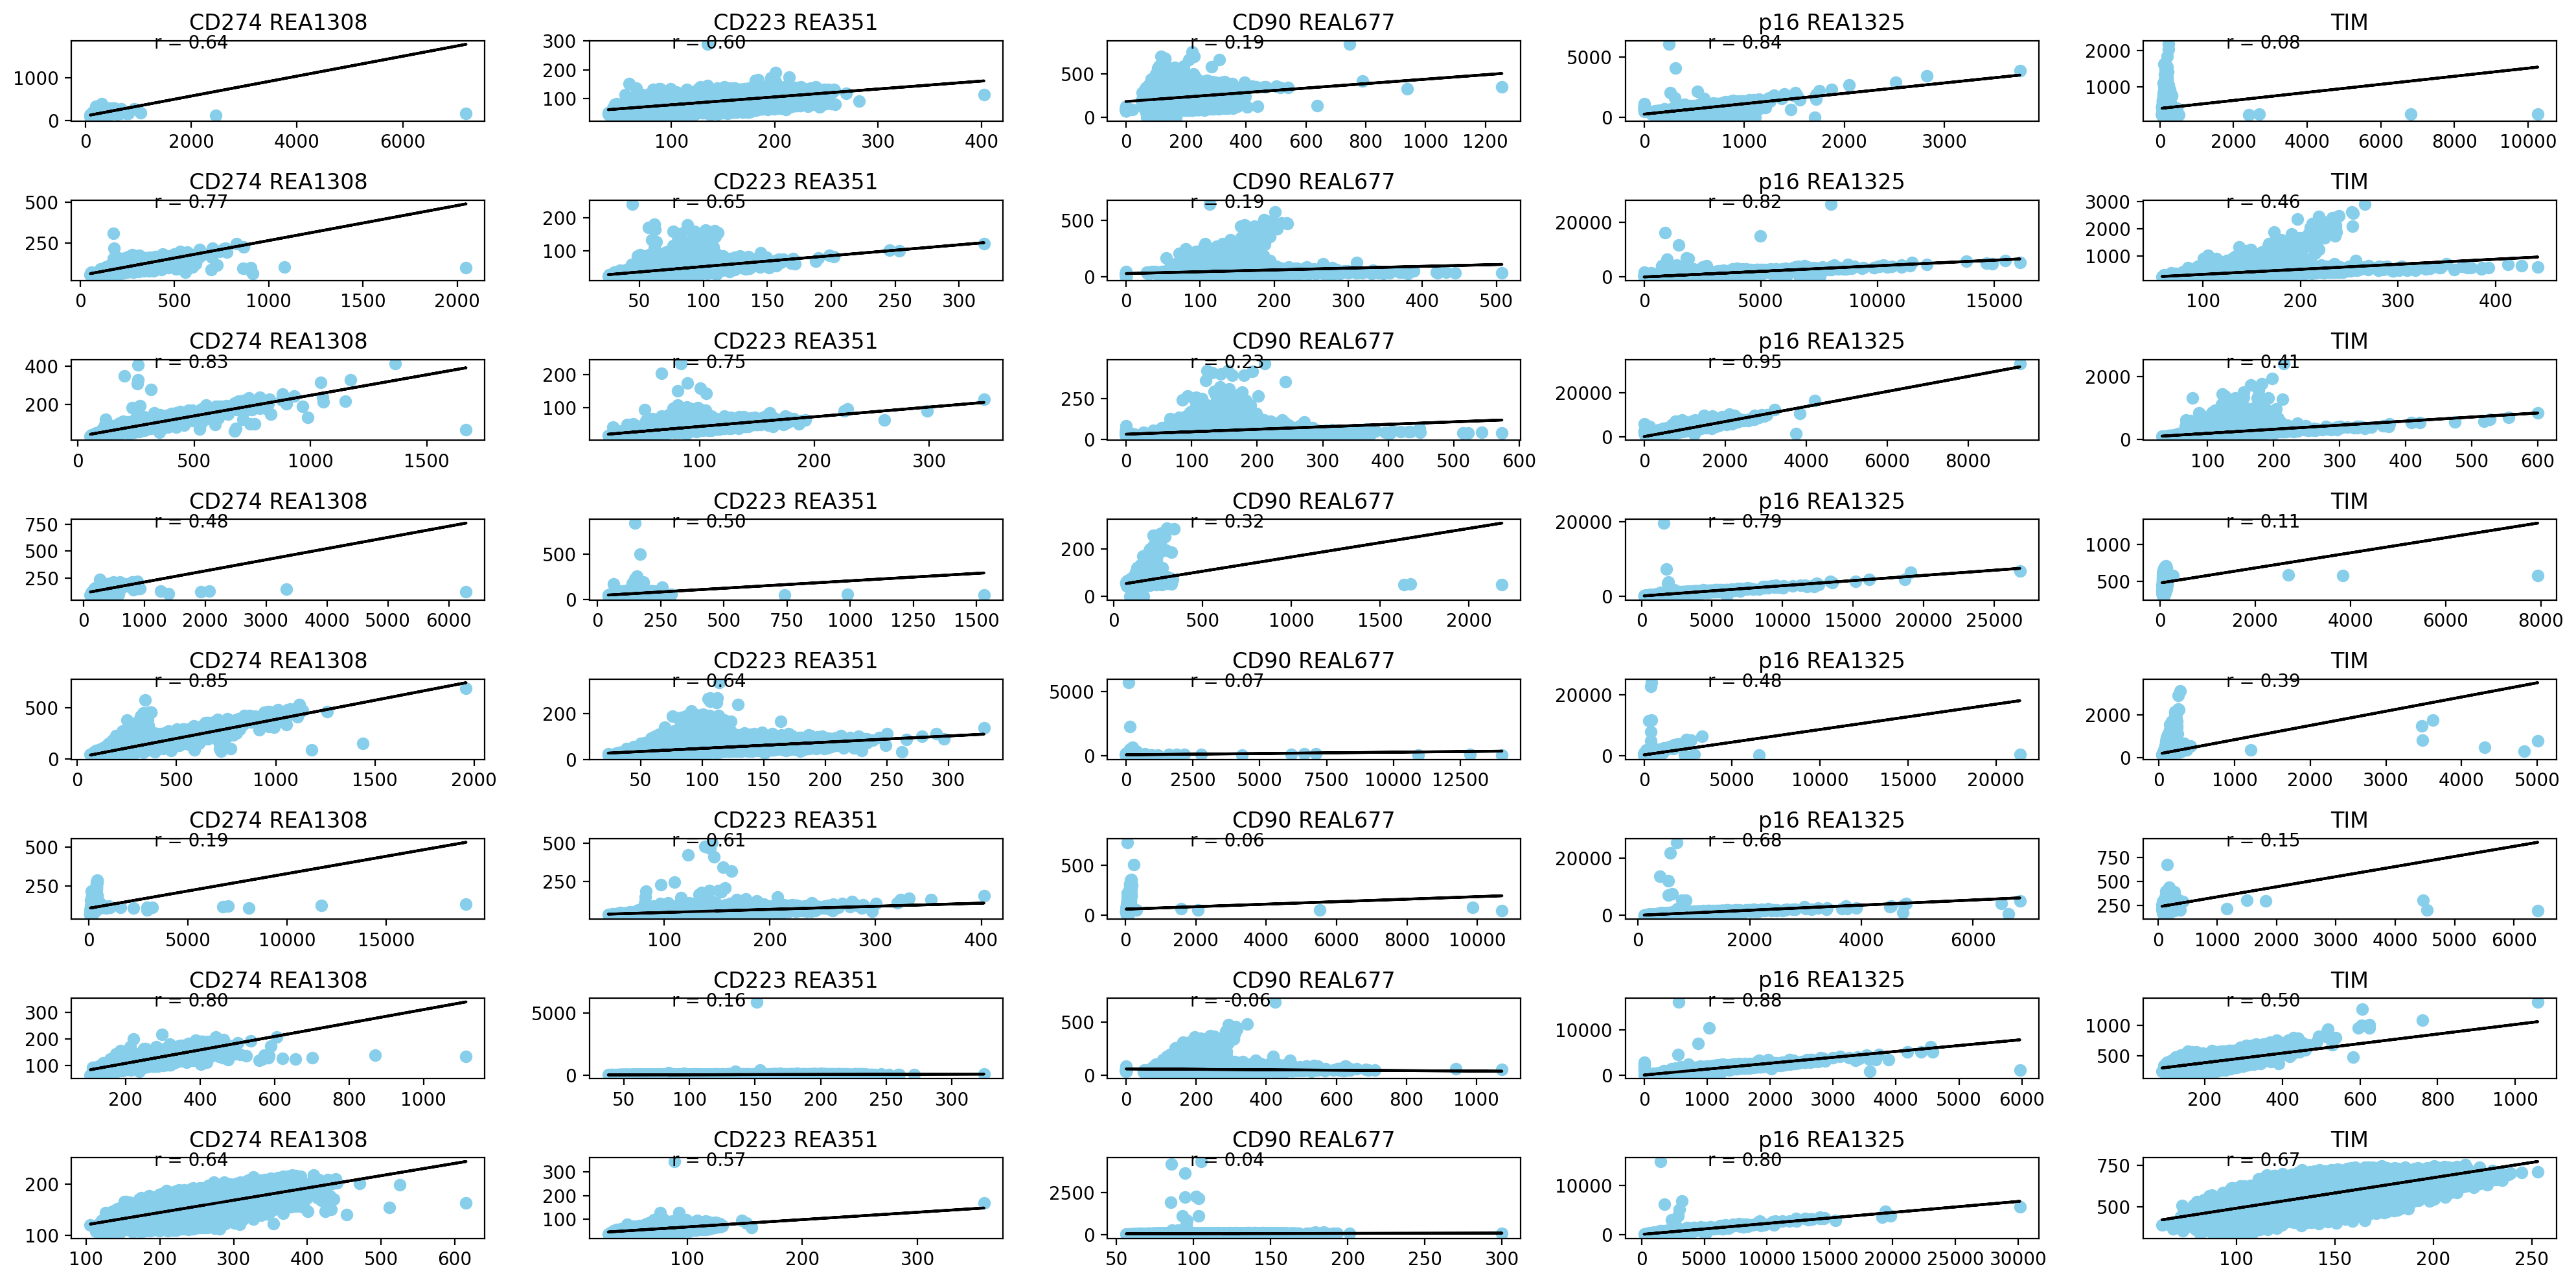

In [21]:
fig, axes = plt.subplots(len(roi_list), len(duplicated_antibodies), figsize=(20, 10))

for i, roi in enumerate(roi_list):
    exp = pd.read_csv(roi / 'exp.csv')
    for j, marker in enumerate(duplicated_antibodies):
        exp_filter = exp.filter(like = marker)
        x = exp_filter.iloc[:,0]
        y = exp_filter.iloc[:,1]
        axes[i,j].scatter(x, y, color='skyblue')
        b, a = np.polyfit(x, y, deg=1)    
        axes[i,j].plot(x, a + b * x, color="k")
        #calculate linear correlation coefficient and add it to the plot
        corr = np.corrcoef(x, y)[0,1]
        axes[i,j].text(0.2, 0.9, "r = {:.2f}".format(corr), transform=axes[i,j].transAxes)
        axes[i,j].set_title(marker)

fig.tight_layout()

## Averaging the duplicates

In [22]:
#let's average the expression of the duplicated antibodies
for roi in roi_list:
    exp = pd.read_csv(roi / 'exp.csv')
    for marker in duplicated_antibodies:
        exp_filter = exp.filter(like = marker)
        exp = exp.loc[:, ~exp.columns.str.contains(marker)]
        exp[marker] = exp_filter.mean(axis=1)
    #rename the TIM column to TIM-3 REAL818
    exp.rename(columns={"TIM": "TIM-3 REAL818"}, inplace=True)
    exp.to_csv(roi / 'exp.csv', index=False)
